In [2]:
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_core.messages import  HumanMessage


In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description='Query Arxiv Papers')


In [4]:
print(arxiv)

description='Query Arxiv Papers' api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)


In [5]:
print(arxiv.invoke('Attention is all you need'))

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [9]:
wikipedia_wrapper = WikipediaAPIWrapper(top_k_results=3)
wikipedia = WikipediaQueryRun(api_wrapper=wikipedia_wrapper)

wikipedia.invoke('Albert Einstein')


'Page: Albert Einstein\nSummary: Albert Einstein (14 March 1879 – 18 April 1955) was a German-born theoretical physicist best known for developing the theory of relativity. Einstein also made important contributions to quantum theory. His mass–energy equivalence formula E = mc2, which arises from special relativity, has been called "the world\'s most famous equation". He received the 1921 Nobel Prize in Physics for "his services to theoretical physics, and especially for his discovery of the law of the photoelectric effect".\nBorn in the German Empire, Einstein moved to Switzerland in 1895, forsaking his German citizenship the following year. In 1897, at the age of seventeen, he enrolled in the mathematics and physics teaching diploma program at the Swiss federal polytechnic school in Zurich, graduating in 1900. He acquired Swiss citizenship a year later, which he kept for the rest of his life, and afterwards secured a permanent position at the Swiss Patent Office in Bern. In 1905, he 

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_tavily.tavily_search import TavilySearch

tavily = TavilySearch()
tavily.invoke('First US soldiers to die in Iran conflict')

{'query': 'First US soldiers to die in Iran conflict',
 'response_time': 0.84,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.bbc.com/news/articles/c4gq33ynl07o',
   'title': 'First US soldiers to die in Iran conflict are identified',
   'content': "# Six US soldiers killed in Iranian strike on Kuwait base. The US embassy in Bayan, Kuwait, was also struck during an Iranian attack. Six American soldiers were killed in an Iranian strike against a military facility in Kuwait on Sunday, the US has confirmed. Defence Secretary Pete Hegseth confirmed a US bunker in Kuwait was hit after a missile was launched during Iran's original retaliation evaded air defences. The six deaths are the only fatalities confirmed by the US military since it launched a new war against Iran with Israel. Three US military officials with direct knowledge of Iran's attack told the BBC's US partner CBS News that the service members were in a makeshift office space in 

In [10]:
tools = [arxiv,wikipedia,tavily]

In [11]:
from langchain_groq import ChatGroq

llm = ChatGroq(model='openai/gpt-oss-20b')


In [10]:
llm.invoke('What is AI')


AIMessage(
    content='**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating systems capable of performing tasks that normally require human intelligence. These tasks include:\n\n| Category | Examples | Typical Techniques |\n|----------|----------|--------------------|\n| **Perception** | Vision, speech, and language understanding | Convolutional Neural Networks (CNNs), Recurrent Neural Networks (RNNs), Transformers |\n| **Reasoning & Planning** | Problem solving, decision making | Logic programming, search algorithms, probabilistic models |\n| **Learning** | Adapting from data | Supervised, unsupervised, reinforcement learning |\n| **Interaction** | Dialogue, user interfaces | Natural Language Processing (NLP), dialogue systems |\n\n### Core Concepts\n\n1. **Machine Learning (ML)** – The most common subset of AI, where models learn patterns from data.\n2. **Neural Networks** – Inspired by the brain’s structure; deep learning uses many layers to ex

In [12]:
superllm = llm.bind_tools(tools)

In [11]:
superllm.invoke('Tell me about Recent Israel Iran Conflict and latest news about the same')


AIMessage(
    content='',
    additional_kwargs={
        'reasoning_content': "We need to provide recent info on Israel-Iran conflict. Likely referencing recent events like Iran's missile launch, Israeli responses, etc. We should browse for up-to-date info. Use tavily_search.",
        'tool_calls': [
            {
                'id': 'fc_2a7c1968-d841-4162-8014-69bed4830bdc',
                'function': {
                    'arguments': '{"query":"Israel Iran conflict latest news 2026","search_depth":"advanced","topic":"news"}',
                    'name': 'tavily_search'
                },
                'type': 'function'
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 84,
            'prompt_tokens': 410,
            'total_tokens': 494,
            'completion_time': 0.08439918,
            'completion_tokens_details': {'reasoning_tokens': 43},
            'prompt_time': 0.0085957,
            'prompt_tokens_d

In [13]:
from typing import Annotated,TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph import START,END,StateGraph


In [14]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

In [15]:
def start_call(state:State) -> State:
    return {'messages':[superllm.invoke(state['messages'])]} 

In [16]:
tool_node = ToolNode(tools)

In [17]:
graph = StateGraph(State)
graph.add_node('start_llm',start_call)
graph.add_node('tools',tool_node)

graph.add_edge(START,'start_llm')
graph.add_conditional_edges('start_llm',tools_condition)
graph.add_edge('tools','start_llm')

workflow = graph.compile()

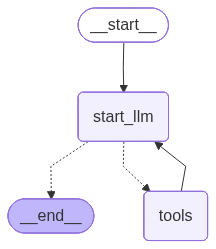

In [18]:
workflow

In [18]:
result = workflow.invoke({'messages':[HumanMessage(content='1706.03762')]})

In [19]:
print(result['messages'])

[
    HumanMessage(
        content='1706.03762',
        additional_kwargs={},
        response_metadata={},
        id='2b7f5bd3-ea03-424c-b096-4d25859486ef'
    ),
    AIMessage(
        content='',
        additional_kwargs={
            'reasoning_content': 'The user provided "1706.03762" which is likely an arXiv identifier for a paper. 
They might want a summary. We can use the arxiv function. Let\'s query it.',
            'tool_calls': [
                {
                    'id': 'fc_c679795d-7e5c-4445-89d7-d6507c026313',
                    'function': {'arguments': '{"query":"1706.03762"}', 'name': 'arxiv'},
                    'type': 'function'
                }
            ]
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 68,
                'prompt_tokens': 402,
                'total_tokens': 470,
                'completion_time': 0.072358176,
                'completion_tokens_details': {'reasoning_tokens': 41},
                'prompt_time': 0.009416607,
                'prompt_tokens_details': {'cached_tokens': 256},
                'queue_time': 0.043128092,
                'total_time': 0.081774783
            },
            'model_name': 'openai/gpt-oss-20b',
            'system_fingerprint': 'fp_80501ff3a1',
            'service_tier': 'on_demand',
            'finish_reason': 'tool_calls',
            'logprobs': None,
            'model_provider': 'groq'
        },
        id='lc_run--019cb8a3-6fee-77d2-bd20-9debd8166838-0',
        tool_calls=[
            {
                'name': 'arxiv',
                'args': {'query': '1706.03762'},
                'id': 'fc_c679795d-7e5c-4445-89d7-d6507c026313',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 402,
            'output_tokens': 68,
            'total_tokens': 470,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 41}
        }
    ),
    ToolMessage(
        content='Published: 2023-08-02\nTitle: Attention Is All You Need\nAuthors: Ashish Vaswani, Noam Shazeer, 
Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin\nSummary: The dominant 
sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder 
configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We 
propose a new simple network architecture, the Transformer, base',
        name='arxiv',
        id='d7515776-5d4a-40ea-b7d7-8ce1abce061f',
        tool_call_id='fc_c679795d-7e5c-4445-89d7-d6507c026313'
    ),
    AIMessage(
        content='**ArXiv Paper: 1706.03762**\n\n- **Title:** *Attention Is All You Need*  \n- **Authors:** Ashish 
Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin  
\n- **Publication Date:** 2017‑06‑12 (arXiv) – later published in *Proceedings of the 31st International Conference
on Neural Information Processing Systems (NeurIPS 2017)*.  \n- **Abstract:**  \n  The dominant sequence 
transduction models are based on complex recurrent or convolutional neural networks in an encoder‑decoder 
configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We 
propose a new simple network architecture, the Transformer, that relies entirely on attention mechanisms, 
dispensing with recurrence and convolutions entirely. The Transformer achieves state‑of‑the‑art results on the WMT 
2014 English‑German translation task while reducing training times by an order of magnitude.  \n\n- **Key 
Contributions:**\n  1. Introduces the *Transformer* architecture, built solely on multi‑head self‑attention and 
position‑wise feed‑forward layers.  \n  2. Demonstrates that attention alone can model long‑range dependencies 
efficiently.

In [27]:
for i in result['messages']:
    print(i.pretty_print())

================================ Human Message =================================

1706.03762


None

================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd)
 Call ID: fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd
  Args:
    query: 1706.03762


None

================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


...

None

================================= Tool Message =================================
Name: tavily_search

{"query": "arXiv 1706.03762", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://arxiv.org/abs/1706.03762", "title": "[1706.03762] Attention Is All You Need - arXiv", "content": "[Skip to main content](https://arxiv.org/abs/1706.03762#content). *   [Login](https://arxiv.org/login). *   [Help Pages](https://info.arxiv.org/help). *   [About](https://info.arxiv.org/about). [Submitted on 12 Jun 2017 ([v1](https://arxiv.org/abs/1706.03762v1)), last revised 2 Aug 2023 (this version, v7)]. [View PDF](https://arxiv.org/pdf/1706.03762)[HTML (experimental)](https://arxiv.org/html/1706.03762v7). Cite as:[arXiv:1706.03762](https://arxiv.org/abs/1706.03762) [cs.CL]. (or [arXiv:1706.03762v7](https://arxiv.org/abs/1706.03762v7) [cs.CL] for this version). **[[v1]](https://arxiv.org/abs/1706.03762v1)** Mon, 12 Jun 2017 17:57:34 UTC (1,102 KB). **[[v2]](https://arxiv

None

================================== Ai Message ==================================

**arXiv 1706.03762 – “Attention Is All You Need”**

| Item | Details |
|------|---------|
| **Title** | *Attention Is All You Need* |
| **Authors** | Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin |
| **Submitted** | 12 Jun 2017 (v1) – last revised 2 Aug 2023 (v7) |
| **Subject** | Computer Science – Computation and Language (cs.CL) |
| **Abstract** | The dominant sequence‑to‑sequence models at the time relied on complex recurrent or convolutional encoder‑decoder architectures.  The authors propose a **purely attention‑based** architecture, the *Transformer*, that eliminates recurrence and convolution entirely.  The model uses multi‑headed self‑attention and a simple positional encoding scheme to capture sequence order.  On the WMT 2014 English‑German translation task the Transformer achieves a BLEU score of **28.4** (single‑model),

None

In [20]:
result['messages'][-1].content

'**ArXiv Paper: 1706.03762**\n\n- **Title:** *Attention Is All You Need*  \n- **Authors:** Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin  \n- **Publication Date:** 2017‑06‑12 (arXiv) – later published in *Proceedings of the 31st International Conference on Neural Information Processing Systems (NeurIPS 2017)*.  \n- **Abstract:**  \n  The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder‑decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, that relies entirely on attention mechanisms, dispensing with recurrence and convolutions entirely. The Transformer achieves state‑of‑the‑art results on the WMT 2014 English‑German translation task while reducing training times by an order of magnitude.  \n\n- **Key Contributions:**\n  

## Memory in Chatbot

In [19]:
from langgraph.checkpoint.memory import MemorySaver

In [20]:
memory = MemorySaver()
workflow = graph.compile(checkpointer=memory)

In [21]:
config = {'configurable':{'thread_id':'1'}}

In [22]:
res = workflow.invoke({'messages':'Hi, my name is Krish'},config=config)

In [23]:
res

{'messages': [HumanMessage(content='Hi, my name is Krish', additional_kwargs={}, response_metadata={}, id='f13d6641-4ab3-4bbc-ba75-37d3a8d05551'),
  AIMessage(content='Hello Krish! How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi, my name is Krish". Likely wants a greeting. No request. I can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 404, 'total_tokens': 450, 'completion_time': 0.046508559, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.008342331, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.043089469, 'total_time': 0.05485089}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb8b4-ba67-71e3-b267-21d3d1ee45e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 404, 'output_tokens': 46, 'total_t

In [26]:
res = workflow.invoke({'messages':'Hi, Do you know my name'},config=config)
res['messages'][-1].content


'Yes, you just told me—your name is Krish! If there’s anything else you’d like to share or ask, feel free.'

In [25]:
for chunk,metadata in workflow.stream({'messages':'Essay on Batman'},config={'configurable':{'thread_id':'3'}},stream_mode='messages'):
    if chunk.content:
        print(chunk.content,end='',flush=True)

**Batman: The Shadow That Became a Symbol**

*From a comic strip to a global myth, Batman’s journey is a study in how a single idea can evolve into a cultural phenomenon.*

---

### I.  The Birth of a Dark Hero

When *Detective Comics* #27 hit newsstands on March 30, 1939, the world had just witnessed the rise of the first superhero, Superman. Yet the cover art that month would forever change the genre: a young Bruce Wayne, dressed in a cape and cowl, standing atop a Gotham City rooftop, staring out at the night. The idea was simple yet revolutionary—an ordinary man using his intellect, training, and resources to fight crime without any supernatural powers.

Behind the mask was Bill Finger, the unsung architect of Batman’s mythology. Finger’s insistence on a grounded origin (the murder of Bruce’s parents), the introduction of a bat as a symbol, and the creation of iconic villains like the Joker, were the seeds that grew into a living legend. Batman was not just a hero; he was a mirror 